In [144]:
import json
from pathlib import Path

from collections import defaultdict

from app.schemas import ModelEvaluation, GradingResult, KeyConcepts

In [145]:
dir_path = Path("../output")

In [146]:
data: list[ModelEvaluation] = []

for model_dir in dir_path.iterdir():
    if model_dir.is_file():
        continue
    
    for temperature_dir in model_dir.iterdir():
        if temperature_dir.is_file():
            continue

        for evaluation_file in temperature_dir.iterdir():
            if evaluation_file.is_dir():
                continue

            content = evaluation_file.read_text(encoding="utf8")
            model_evaluation = ModelEvaluation.model_validate(json.loads(content))
            data.append(model_evaluation)

In [147]:
def calc_score(grading_result: GradingResult, key_concepts: KeyConcepts):
    global wrong
    global correct
    score = 0
    for i, concept_score in enumerate(grading_result.concepts):
        try:
            concept = key_concepts.concepts[concept_score.id - 1]
        except IndexError as e:
            raise ValueError("Wrong concept id")
        
        score += concept_score.coverage * concept.importance

    total_possible = sum(x.importance for x in key_concepts.concepts) * 2

    return score / total_possible * 100

In [148]:
metrics = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))

In [149]:
tolerance = 10

In [150]:
for item in data:
    try:
        grade_score = calc_score(item.grading_results, item.key_concepts)
    except ValueError as e:
        continue
    
    real_score = item.answer.quality

    error = real_score - grade_score
    metrics[item.model][item.temperature]["mae"] += abs(error)
    metrics[item.model][item.temperature]["mse"] += error ** 2
    metrics[item.model][item.temperature]["valid_examples"] += 1

    if real_score - tolerance <= grade_score <= real_score + tolerance:
        metrics[item.model][item.temperature]["correct estimation"] += 1
    elif grade_score < real_score - tolerance * 2:
        metrics[item.model][item.temperature]["super low estimation"] += 1
    elif grade_score > real_score + tolerance * 2:
        metrics[item.model][item.temperature]["super over estimation"] += 1
    elif grade_score < real_score - tolerance:
        metrics[item.model][item.temperature]["low estimation"] += 1
    else:
        metrics[item.model][item.temperature]["over estimation"] += 1

In [151]:
metrics

defaultdict(<function __main__.<lambda>()>,
            {'llama3-8b': defaultdict(<function __main__.<lambda>.<locals>.<lambda>()>,
                         {0.5: defaultdict(float,
                                      {'mae': 328.3271185115698,
                                       'mse': 7069.114022059145,
                                       'valid_examples': 25.0,
                                       'super over estimation': 3.0,
                                       'correct estimation': 14.0,
                                       'low estimation': 4.0,
                                       'super low estimation': 4.0}),
                          0.7: defaultdict(float,
                                      {'mae': 392.79952313946217,
                                       'mse': 11190.149311860738,
                                       'valid_examples': 25.0,
                                       'correct estimation': 13.0,
                                       'low e

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [153]:
models = list(metrics.keys())
temps = sorted(metrics[models[0]].keys())

data_mae = {}
data_mse = {}
for model in models:
    data_mae[model] = [metrics[model][t]["mae"] for t in temps]
    data_mse[model] = [metrics[model][t]["mse"] for t in temps]

df_mae = pd.DataFrame(data_mae, index=temps)
df_mse = pd.DataFrame(data_mse, index=temps)

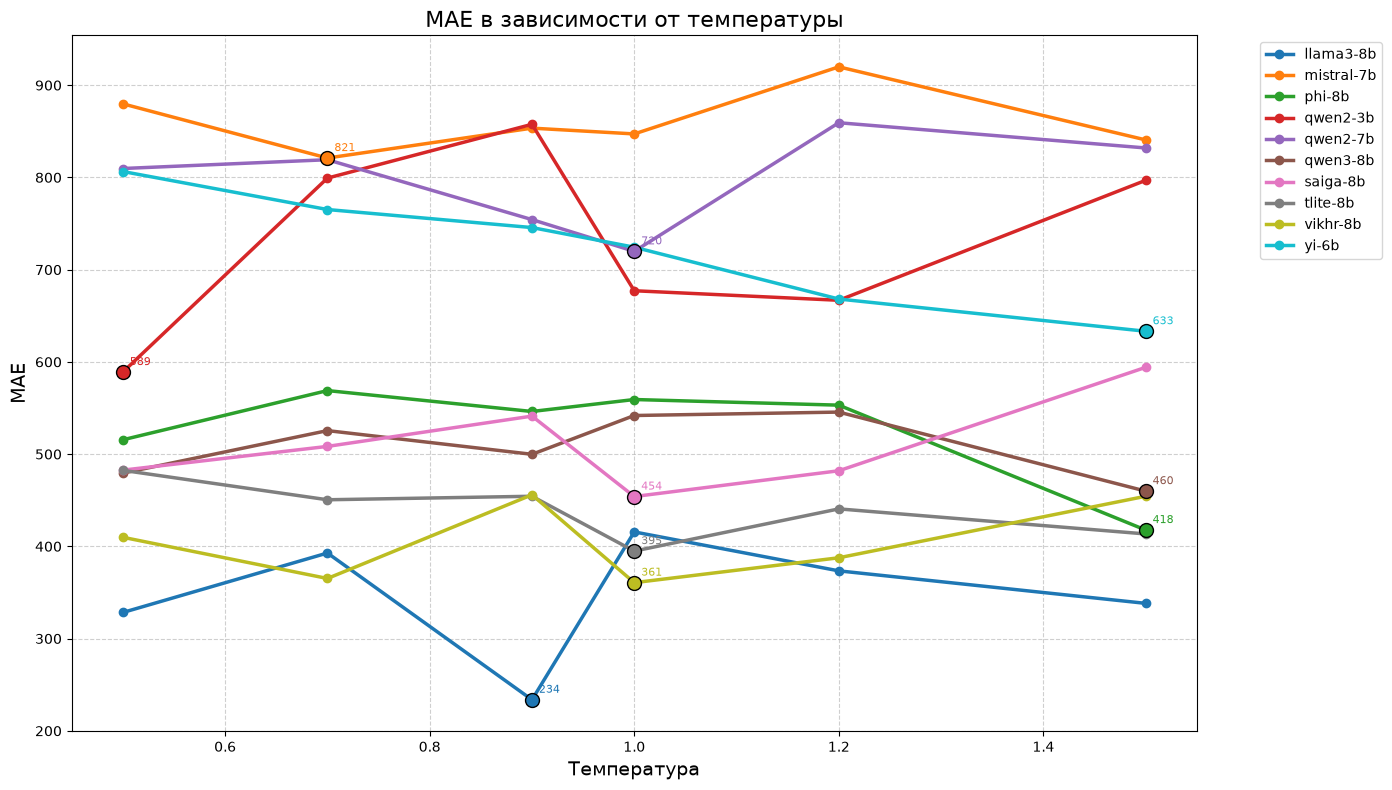

In [154]:
plt.figure(figsize=(14, 8))
palette = sns.color_palette("tab10", n_colors=len(models))

for i, model in enumerate(models):
    plt.plot(temps, df_mae[model], marker='o', linewidth=2.5, label=model, color=palette[i])

    min_mae = df_mae[model].min()
    min_temp = df_mae[model].idxmin()
    plt.scatter(min_temp, min_mae, s=100, color=palette[i], edgecolor='black', zorder=5)
    plt.annotate(f'{min_mae:.0f}', 
                 (min_temp, min_mae), 
                 xytext=(5, 5), 
                 textcoords='offset points',
                 fontsize=8, color=palette[i])

plt.xlabel('Температура', fontsize=14)
plt.ylabel('MAE', fontsize=14)
plt.title('MAE в зависимости от температуры', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

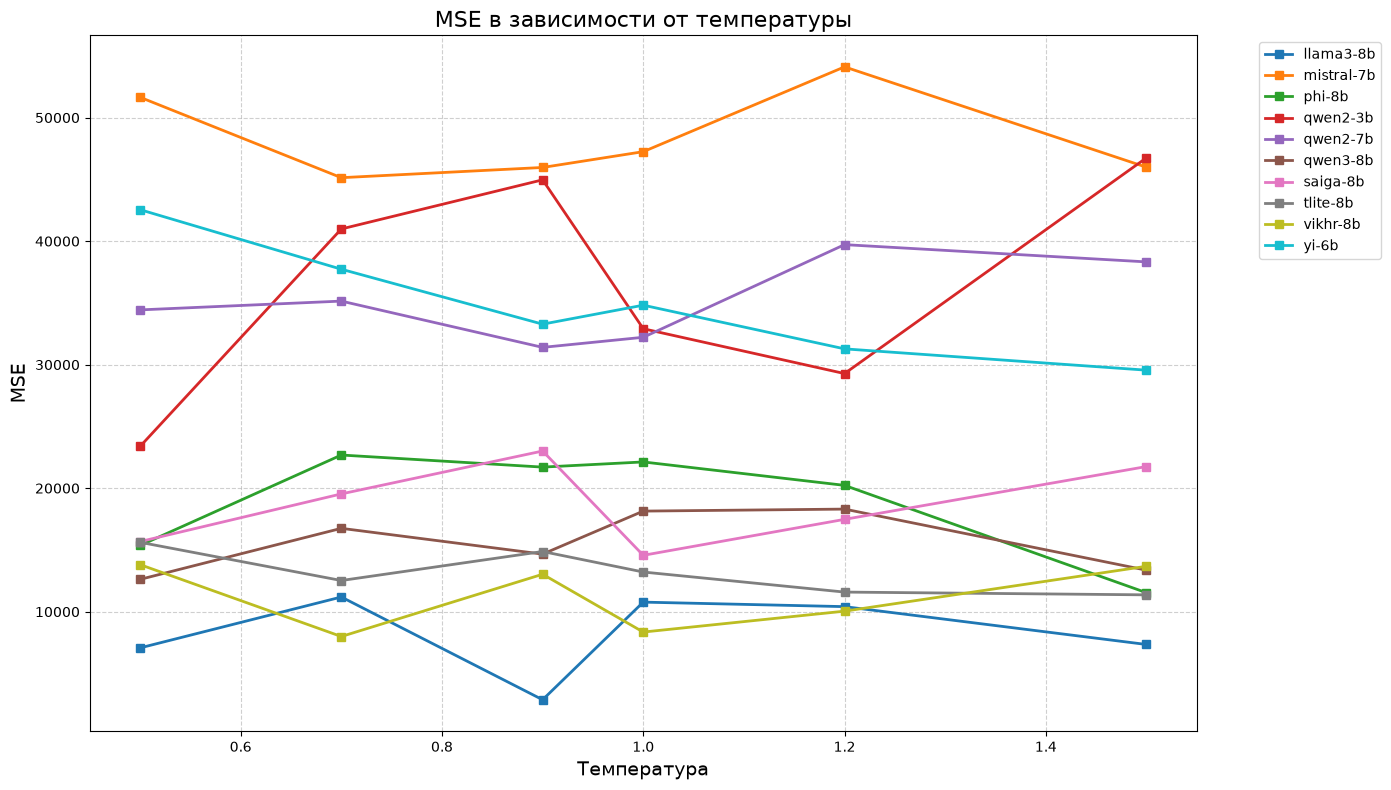

In [ ]:
plt.figure(figsize=(14, 8))
for i, model in enumerate(models):
    plt.plot(temps, df_mse[model], marker='s', linewidth=2, label=model, color=palette[i])

plt.xlabel('Температура', fontsize=14)
plt.ylabel('MSE', fontsize=14)
plt.title('MSE в зависимости от температуры', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()